# CMIP6 Historical Zonal-Velocity Sections

This notebook finds historical CMIP6 ocean models with zonal velocity, salinity, and at least one temperature variable. It selects the first valid ensemble member for each model, keeps only 2000-2010 data in the tropical Pacific, creates lazy 9.5N time-mean sections, and creates lazy longitude-mean profiles. No TEOS-10 or derived thermodynamic variables are calculated in this version.


## 1. Configuration and Imports

The geographic domain is 180W-80W and 20S-20N. The profile averaging window is 159W-104.25W. All data operations remain lazy until the dedicated loading cell near the end.


In [1]:
import intake
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.diagnostics import ProgressBar
from tqdm.auto import tqdm

PANGEO_CMIP6_CATALOG = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
TIME_START = 2000
TIME_END = 2010
LATITUDE_MIN = -20
LATITUDE_MAX = 20
LONGITUDE_MIN_360 = 180
LONGITUDE_MAX_360 = 280
SECTION_LATITUDE = 9.5
PROFILE_LON_MIN_360 = 201
PROFILE_LON_MAX_360 = 255.75

LATITUDE_NAMES = ("lat", "latitude", "nav_lat", "geolat")
LONGITUDE_NAMES = ("lon", "longitude", "nav_lon", "geolon")
DEPTH_NAMES = ("lev", "olevel", "depth", "deptht", "z")
TEMPERATURE_VARIABLES = ("thetao", "to", "CT")
SALINITY_VARIABLE = "so"
VELOCITY_VARIABLE = "uo"
DENSITY_VARIABLES = ("rho", "potrho", "sigma0")
CANDIDATE_VARIABLES = (VELOCITY_VARIABLE, SALINITY_VARIABLE, *TEMPERATURE_VARIABLES, *DENSITY_VARIABLES)


/opt/anaconda3/envs/cmip6_query/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Query the Archive and Build the Model Plan

The catalog query is metadata-only. For each source model, the plan chooses the first ensemble member that contains zonal velocity, salinity, and one supported temperature variable. The table reports the variable and grid label for each selected run; density is recorded when available but is not loaded or calculated below.


In [2]:
cmip6 = intake.open_esm_datastore(PANGEO_CMIP6_CATALOG)
records = cmip6.search(
    experiment_id="historical",
    table_id="Omon",
    variable_id=list(CANDIDATE_VARIABLES),
).df.copy()


def ensemble_sort_key(member_id):
    parts = member_id.replace("r", "").replace("i", " ").replace("p", " ").replace("f", " ")
    return tuple(map(int, parts.split()))


def make_model_plan(records):
    plans = []
    for source_id, source_records in records.groupby("source_id"):
        for member_id in sorted(source_records["member_id"].dropna().unique(), key=ensemble_sort_key):
            member_records = source_records[source_records["member_id"] == member_id]
            available = set(member_records["variable_id"])
            temperature_name = next((name for name in TEMPERATURE_VARIABLES if name in available), None)
            required = {VELOCITY_VARIABLE, SALINITY_VARIABLE, temperature_name}
            if temperature_name is None or not required.issubset(available):
                continue

            variable_names = {
                "uo": VELOCITY_VARIABLE,
                "temperature": temperature_name,
                "so": SALINITY_VARIABLE,
            }
            selected = {"source_id": source_id, "member_id": member_id}
            for label, variable_name in variable_names.items():
                variable_records = member_records[member_records["variable_id"] == variable_name]
                if variable_records.empty:
                    break
                selected[f"{label}_variable"] = variable_name
                selected[f"{label}_grid_label"] = sorted(variable_records["grid_label"].dropna().unique())[0]
            else:
                density_name = next((name for name in DENSITY_VARIABLES if name in available), None)
                selected["density_variable"] = density_name
                selected["density_grid_label"] = (
                    sorted(member_records.loc[member_records["variable_id"] == density_name, "grid_label"].dropna().unique())[0]
                    if density_name is not None else None
                )
                plans.append(selected)
                break
    return pd.DataFrame(plans).sort_values("source_id", ignore_index=True)


model_plan = make_model_plan(records)
plan_columns = [
    "source_id", "member_id",
    "temperature_variable", "temperature_grid_label",
    "so_variable", "so_grid_label",
    "uo_variable", "uo_grid_label",
    "density_variable", "density_grid_label",
]
print(f"Eligible historical models: {len(model_plan)}")
display(model_plan[plan_columns])


Eligible historical models: 48


,source_id,member_id,temperature_variable,temperature_grid_label,so_variable,so_grid_label,uo_variable,uo_grid_label,density_variable,density_grid_label
0,ACCESS-CM2,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
1,ACCESS-ESM1-5,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
2,AWI-CM-1-1-MR,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
3,AWI-ESM-1-1-LR,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
4,BCC-CSM2-MR,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
5,BCC-ESM1,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
6,CAMS-CSM1-0,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
7,CESM2,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
8,CESM2-FV2,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None
9,CESM2-WACCM,r1i1p1f1,thetao,gn,so,gn,uo,gn,None,None


## 3. Lazy Model Loading and Geographic Subsetting

Only the selected zonal-velocity variable is opened for the section workflow. The model datasets are restricted lazily to 180W-80W and 20S-20N. No values are loaded into memory here, and temperature, salinity, and density arrays are not opened.


In [3]:
def find_coordinate(data, candidates, standard_name):
    for name in candidates:
        if name in data.coords:
            return name
    for name, coordinate in data.coords.items():
        if coordinate.attrs.get("standard_name") == standard_name:
            return name
    raise KeyError(f"No {standard_name!r} coordinate found; available: {list(data.coords)}")


def subset_region(data):
    latitude_name = find_coordinate(data, LATITUDE_NAMES, "latitude")
    longitude_name = find_coordinate(data, LONGITUDE_NAMES, "longitude")
    latitude = data[latitude_name]
    longitude_360 = data[longitude_name] % 360
    region = (
        (latitude >= LATITUDE_MIN)
        & (latitude <= LATITUDE_MAX)
        & (longitude_360 >= LONGITUDE_MIN_360)
        & (longitude_360 <= LONGITUDE_MAX_360)
    )
    return data.where(region.compute(), drop=True)


def open_uo(plan):
    query = {
        "source_id": plan.source_id,
        "member_id": plan.member_id,
        "experiment_id": "historical",
        "table_id": "Omon",
        "grid_label": plan.uo_grid_label,
        "variable_id": VELOCITY_VARIABLE,
    }
    datasets = cmip6.search(**query).to_dataset_dict(
        zarr_kwargs={"consolidated": True},
        storage_options={"token": "anon"},
    )
    matches = [dataset[[VELOCITY_VARIABLE]] for dataset in datasets.values() if VELOCITY_VARIABLE in dataset]
    if len(matches) != 1:
        raise ValueError(f"Expected one uo dataset for {plan.source_id}, found {len(matches)}")
    return matches[0]


model_datasets = {}
loading_failures = {}
for _, plan in model_plan.iterrows():
    try:
        model_datasets[plan.source_id] = subset_region(open_uo(plan))
    except Exception as error:
        loading_failures[plan.source_id] = str(error)

print(f"Created {len(model_datasets)} lazy regional model datasets.")
if loading_failures:
    display(pd.DataFrame.from_dict(loading_failures, orient="index", columns=["reason"]))



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:02&lt;00:00]</div>

/opt/anaconda3/envs/cmip6_query/lib/python3.12/site-packages/google/auth/transport/grpc.py:44: FutureWarning: grpcio < 1.83.0 does not support Post-Quantum Cryptography (PQC). Support for non-PQC environments is deprecated. In October 2026, google-auth will raise its minimum requirements to enforce grpcio >= 1.83.0. For more details on Google Cloud's post-quantum security migration, visit: https://cloud.google.com/security/resources/post-quantum-cryptography
  warnings.warn(



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:01&lt;00:00]</div>

...

<div><progress max="1" value="1"></progress> 100.00% [1/1 00:01&lt;00:00]</div>


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:01&lt;00:00]</div>

/opt/anaconda3/envs/cmip6_query/lib/python3.12/site-packages/intake_esm/source.py:109: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 5. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/opt/anaconda3/envs/cmip6_query/lib/python3.12/site-packages/intake_esm/source.py:109: UserWarning: The specified chunks separate the stored chunks along dimension "lev" starting at index 67. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/opt/anaconda3/envs/cmip6_query/lib/python3.12/site-packages/intake_esm/source.py:109: UserWarning: The specified chunks separate the stored chunks along dimension "j" starting at index 301. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/opt/anaconda3/envs/cmip6_query/lib/python3.12/

Created 48 lazy regional model datasets.


## 4. Lazy Sections, Time Means, and Longitude-Mean Profiles

For each regional model dataset, this cell selects the section nearest 9.5N, selects only 2000-2010 by integer time indices, computes the time mean, and stores the results without loading values. `model_sections` contains one lazy `xarray.Dataset` per model. `zonal_velocity_profiles` contains one lazy depth-dependent `xarray.DataArray` per model after spatial averaging from 159W to 104.25W.


In [4]:
def extract_section_9_5N(data):
    latitude_name = find_coordinate(data, LATITUDE_NAMES, "latitude")
    longitude_name = find_coordinate(data, LONGITUDE_NAMES, "longitude")
    latitude = data[latitude_name]

    if latitude.ndim == 1:
        available = latitude.where(latitude <= SECTION_LATITUDE, drop=True)
        target = float(available.max().item())
        section = data.sel({latitude_name: target}, method="nearest")
    elif latitude.ndim == 2:
        row_dim, horizontal_dim = latitude.dims
        lat_profile = latitude.mean(dim=horizontal_dim, skipna=True)
        available = lat_profile.where(lat_profile <= SECTION_LATITUDE, drop=True)
        target = float(available.max().item())
        row_index = int(np.argmin(np.abs(lat_profile.values - target)))
        section = data.isel({row_dim: row_index})
    else:
        raise ValueError(f"Unsupported latitude dimensions: {latitude.dims}")

    longitude_360 = section[longitude_name] % 360
    mask = (longitude_360 >= LONGITUDE_MIN_360) & (longitude_360 <= LONGITUDE_MAX_360)
    if not bool(mask.any().item()):
        raise ValueError("No long itudes remain in the requested regional domain")
    return section.where(mask, drop=True).sortby(longitude_name)[[VELOCITY_VARIABLE]]


model_sections = {}
zonal_velocity_profiles = {}
section_failures = {}
for model_name, dataset in model_datasets.items():
    try:
        section = extract_section_9_5N(dataset)
        velocity = section[VELOCITY_VARIABLE]
        depth_name = find_coordinate(velocity, DEPTH_NAMES, "depth")
        time_name = find_coordinate(velocity, ("time",), "time")
        years = velocity[time_name].dt.year.values
        time_indices = np.flatnonzero((years >= TIME_START) & (years <= TIME_END))
        if time_indices.size == 0:
            raise ValueError("No data from 2000 through 2010")

        time_mean = velocity.isel({time_name: time_indices}).mean(time_name, keep_attrs=True)
        depth_units = str(time_mean[depth_name].attrs.get("units", "")).lower()
        if depth_units in {"cm", "centimeter", "centimeters"}:
            time_mean = time_mean.assign_coords({depth_name: time_mean[depth_name] / 100.0})
        elif depth_units in {"mm", "millimeter", "millimeters"}:
            time_mean = time_mean.assign_coords({depth_name: time_mean[depth_name] / 1000.0})
        time_mean[depth_name].attrs = {
            **time_mean[depth_name].attrs,
            "units": "m",
            "long_name": "Ocean depth, positive downward",
        }
        time_mean_dataset = time_mean.to_dataset(name=VELOCITY_VARIABLE)
        time_mean_dataset.attrs.update(source_id=model_name, period="2000-2010")
        model_sections[model_name] = time_mean_dataset

        longitude_name = find_coordinate(time_mean, LONGITUDE_NAMES, "longitude")
        longitude = time_mean[longitude_name] % 360
        longitude_dim = longitude.dims[-1]
        profile_region = time_mean.where(
            (longitude >= PROFILE_LON_MIN_360) & (longitude <= PROFILE_LON_MAX_360),
            drop=True,
        )
        profile_dims = [dim for dim in profile_region.dims if dim != depth_name]
        zonal_velocity_profiles[model_name] = profile_region.mean(
            dim=profile_dims, keep_attrs=True
        ).rename("uo_mean_profile")
    except Exception as error:
        section_failures[model_name] = str(error)

print(f"Created {len(model_sections)} lazy time-mean sections.")
print(f"Created {len(zonal_velocity_profiles)} lazy longitude-mean profiles.")
if section_failures:
    display(pd.DataFrame.from_dict(section_failures, orient="index", columns=["reason"]))


Created 43 lazy time-mean sections.
Created 43 lazy longitude-mean profiles.


,reason
AWI-CM-1-1-MR,index must be monotonic increasing or decreasing
AWI-ESM-1-1-LR,index must be monotonic increasing or decreasing
NorCPM1,No data from 2000 through 2010
NorESM2-LM,"""No 'depth' coordinate found; available: ['i',..."
NorESM2-MM,"""No 'depth' coordinate found; available: ['i',..."


## 5. Load the Prepared Dictionaries into Memory

This is the only cell that loads the prepared section and profile dictionaries. The remote archive is not accessed by the plotting cells below, so plots can be edited and rerun quickly after this cell completes.


In [5]:
# Compute all prepared sections with Dask, then derive profiles from loaded sections.
# Dask parallelizes section reads; profiles reuse those in-memory sections.
section_names = sorted(model_sections)
section_tasks = [model_sections[model_name] for model_name in section_names]

with ProgressBar():
    loaded_sections = dask.compute(*section_tasks)

model_sections = dict(zip(section_names, loaded_sections))
print(f"Loaded {len(model_sections)} sections into memory.")

zonal_velocity_profiles = {}
for model_name in tqdm(section_names, desc="Computing zonal_velocity_profiles", unit="model"):
    section = model_sections[model_name]
    velocity = section[VELOCITY_VARIABLE]
    depth_name = find_coordinate(velocity, DEPTH_NAMES, "depth")
    longitude_name = find_coordinate(velocity, LONGITUDE_NAMES, "longitude")
    longitude = velocity[longitude_name] % 360
    profile_region = velocity.where(
        (longitude >= PROFILE_LON_MIN_360) & (longitude <= PROFILE_LON_MAX_360),
        drop=True,
    )
    profile_dims = [dim for dim in profile_region.dims if dim != depth_name]
    zonal_velocity_profiles[model_name] = profile_region.mean(
        dim=profile_dims, keep_attrs=True
    ).rename("uo_mean_profile")

print(f"Computed {len(zonal_velocity_profiles)} in-memory profiles.")


[########################################] | 100% Completed | 3hr 5ms
Loaded 43 sections into memory.


Computing zonal_velocity_profiles: 100%|██████████| 43/43 [00:00<00:00, 638.71model/s]

Computed 43 in-memory profiles.


## 6. Plot All Mean Zonal-Velocity Profiles

The profiles already contain the 2000-2010 time mean and the 159W-104.25W spatial mean. This cell only draws the in-memory profile dictionary.


In [ ]:
# observational data from P04E LADCP
P04E_mean = xr.open_dataset('/Users/afagerheim/Downloads/crest-to-seamounts.uprof.nc')

In [20]:
P04E_mean

<xarray.Dataset> Size: 2kB
Dimensions:   (depth_coordinate: 54)
Dimensions without coordinates: depth_coordinate
Data variables:
    u         (depth_coordinate) float64 432B -0.08889 -0.0271 ... nan nan
    depth     (depth_coordinate) float64 432B 36.0 116.0 216.0 ... nan nan nan
    u.minlim  (depth_coordinate) float64 432B ...
    u.maxlim  (depth_coordinate) float64 432B ...
Attributes:
    varbindata_input_files:  55.0

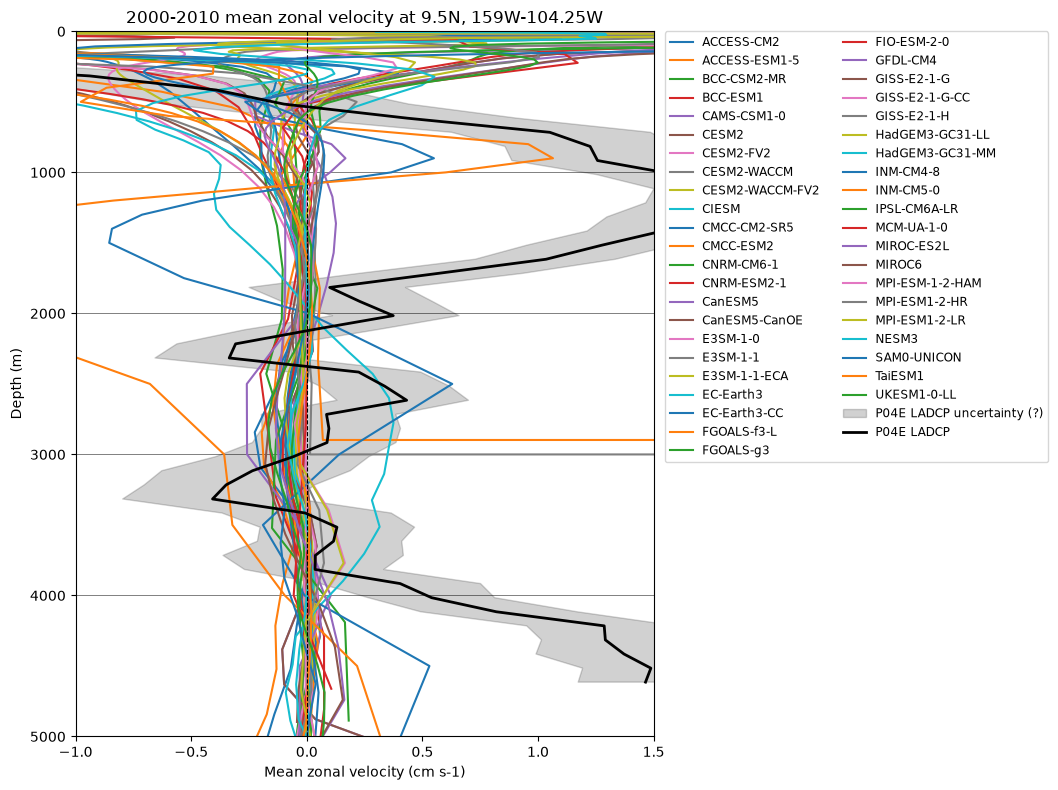

In [53]:
profile_plot_models = sorted(zonal_velocity_profiles)
fig, ax = plt.subplots(figsize=(15, 8))
for model_name in profile_plot_models:
    profile = zonal_velocity_profiles[model_name]
    depth_name = find_coordinate(profile, DEPTH_NAMES, "depth")
    ax.plot(profile.values * 100, profile[depth_name].values, label=model_name)

p04e_depth = P04E_mean["depth"].values
p04e_u = P04E_mean["u"].values * 100
p04e_min = P04E_mean["u.minlim"].values * 100
p04e_max = P04E_mean["u.maxlim"].values * 100
ax.fill_betweenx(
    p04e_depth,
    p04e_min,
    p04e_max,
    color="black",
    alpha=0.18,
    label="P04E LADCP uncertainty (?)",
    zorder=1,
)
ax.plot(p04e_u, p04e_depth, color="black", linewidth=2, label="P04E LADCP", zorder=2)
for depth_level in (1000, 2000, 3000, 4000):
    ax.axhline(depth_level, color="gray", linewidth=0.7, zorder=0)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Mean zonal velocity (cm s-1)")
ax.set_xlim(-1, 1.5)
ax.set_ylabel("Depth (m)")
ax.set_ylim(5000, 0)
ax.set_title("2000-2010 mean zonal velocity at 9.5N, 159W-104.25W")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize="small", ncol=2)
fig.tight_layout(rect=(0, 0, 0.72, 1))
plt.show()


In [ ]:
# NEW PLOT
# Plot a selected model ensemble mean and 95% interval with the P04E LADCP profile.
# Edit this list to choose which models contribute to the blue mean and interval.
EXCLUDED_MODELS = {"FGOALS-f3-L", "GISS-E2-1-H"}
missing_models = sorted(set(MODEL_NAMES) - set(zonal_velocity_profiles))
if missing_models:
    raise KeyError(f"Requested models are unavailable: {missing_models}")
plot_model_names = [
    model_name for model_name in MODEL_NAMES
    if model_name not in EXCLUDED_MODELS
]
ensemble_model_names = [
    model_name for model_name in sorted(zonal_velocity_profiles)
    if model_name not in EXCLUDED_MODELS
]

model_profiles = []
model_profile_names = []
model_max_depths = []
for model_name in ensemble_model_names:
    profile = zonal_velocity_profiles[model_name]
    depth_name = find_coordinate(profile, DEPTH_NAMES, "depth")
    model_depth = np.asarray(profile[depth_name].values, dtype=float)
    model_u = np.asarray(profile.values, dtype=float) * 100.0
    finite = np.isfinite(model_depth) & np.isfinite(model_u)
    if finite.sum() < 2:
        continue
    model_depth = model_depth[finite]
    model_u = model_u[finite]
    order = np.argsort(model_depth)
    model_depth = model_depth[order]
    model_u = model_u[order]
    unique_depth, unique_indices = np.unique(model_depth, return_index=True)
    model_profiles.append((unique_depth, model_u[unique_indices]))
    model_profile_names.append(model_name)
    model_max_depths.append(unique_depth[-1])

if not model_profiles:
    raise ValueError("No finite model profiles are available.")

common_max_depth = float(np.floor(min(model_max_depths) / 50.0) * 50.0)
common_depth = np.arange(0.0, common_max_depth + 50.0, 50.0)
interpolated_profiles = np.full((len(model_profiles), common_depth.size), np.nan)
for index, (model_depth, model_u) in enumerate(model_profiles):
    interpolated_profiles[index] = np.interp(common_depth, model_depth, model_u)

model_mean = np.nanmean(interpolated_profiles, axis=0)
model_lower = np.nanpercentile(interpolated_profiles, 2.5, axis=0)
model_upper = np.nanpercentile(interpolated_profiles, 97.5, axis=0)

p04e_depth = P04E_mean["depth"].values
p04e_u = P04E_mean["u"].values * 100.0
p04e_min = P04E_mean["u.minlim"].values * 100.0
p04e_max = P04E_mean["u.maxlim"].values * 100.0

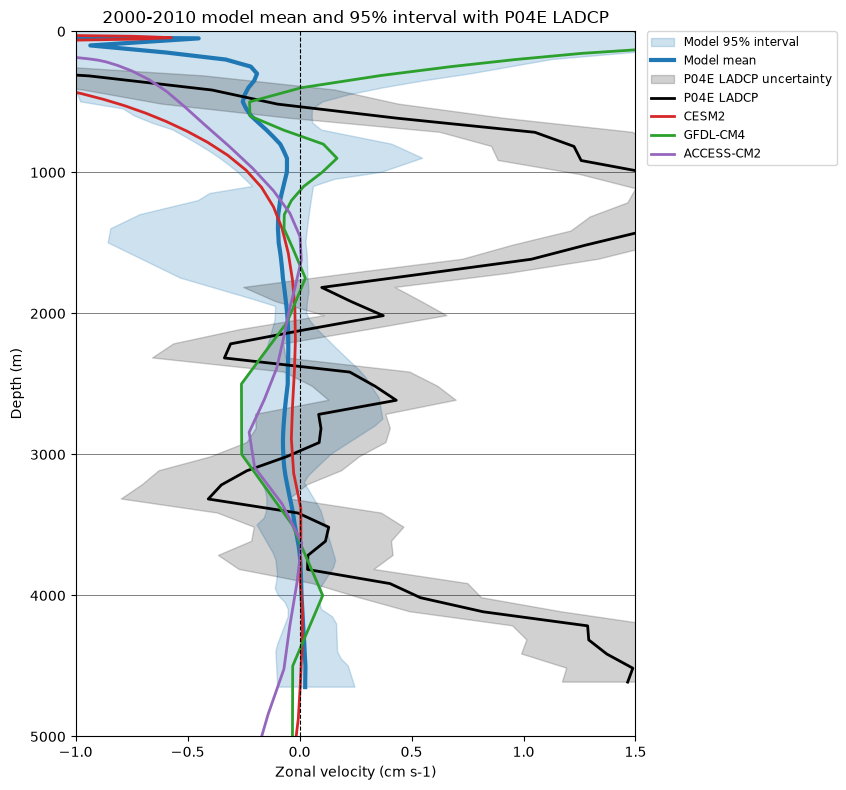

In [84]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.fill_betweenx(common_depth, model_lower, model_upper, color="tab:blue", alpha=0.22, label="Model 95% interval")
ax.plot(model_mean, common_depth, color="tab:blue", linewidth=3, label="Model mean")
ax.fill_betweenx(p04e_depth, p04e_min, p04e_max, color="black", alpha=0.18, label="P04E LADCP uncertainty")
ax.plot(p04e_u, p04e_depth, color="black", linewidth=2, label="P04E LADCP")
ax.plot(zonal_velocity_profiles["CESM2"].values*100, zonal_velocity_profiles["CESM2"].lev, color="tab:red", linewidth=2, label="CESM2")
ax.plot(zonal_velocity_profiles["GFDL-CM4"].values*100, zonal_velocity_profiles["GFDL-CM4"].lev, color="tab:green", linewidth=2, label="GFDL-CM4")
ax.plot(zonal_velocity_profiles["ACCESS-CM2"].values*100, zonal_velocity_profiles["ACCESS-CM2"].lev, color="tab:purple", linewidth=2, label="ACCESS-CM2")
for depth_level in (1000, 2000, 3000, 4000):
    ax.axhline(depth_level, color="gray", linewidth=0.7, zorder=0)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Zonal velocity (cm s-1)")
ax.set_ylabel("Depth (m)")
ax.set_xlim(-1, 1.5)
ax.set_ylim(5000, 0)
ax.set_title("2000-2010 model mean and 95% interval with P04E LADCP")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize="small", ncol=1)
fig.tight_layout(rect=(0, 0, 0.72, 1))
plt.show()

## 7. Plot One Prepared Section

Set `plot_model` to any key in `model_sections` and rerun this cell. The section is already a 2000-2010 time mean, so this cell performs no loading or averaging.


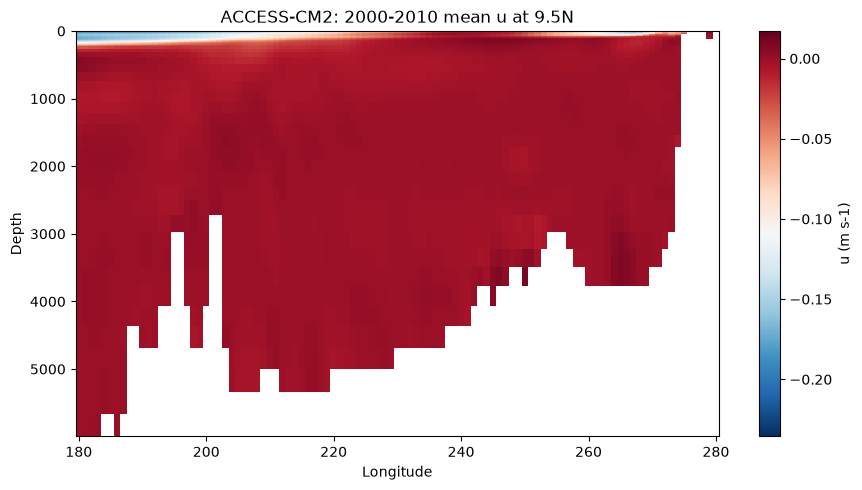

In [22]:
plot_model = sorted(model_sections)[0]
section = model_sections[plot_model]
velocity = section[VELOCITY_VARIABLE]
depth_name = find_coordinate(velocity, DEPTH_NAMES, "depth")
longitude_name = find_coordinate(velocity, LONGITUDE_NAMES, "longitude")
longitude = velocity[longitude_name]
horizontal_dim = longitude.dims[-1]
section_values = velocity.values
if section_values.ndim > 2:
    remaining_dims = [dim for dim in velocity.dims if dim not in {depth_name, horizontal_dim}]
    section_values = velocity.mean(dim=remaining_dims, skipna=True).values

fig, ax = plt.subplots(figsize=(9, 5))
mesh = ax.pcolormesh(
    longitude.values,
    velocity[depth_name].values,
    section_values,
    shading="auto",
    cmap="RdBu_r",
)
fig.colorbar(mesh, ax=ax, label="u (m s-1)")
ax.set_title(f"{plot_model}: 2000-2010 mean u at 9.5N")
ax.set_xlabel("Longitude")
ax.set_ylabel("Depth")
ax.invert_yaxis()
fig.tight_layout()
plt.show()
